# N2 · 自回归生成图像 (Autoregressive Generation)

> 配套 10.4-L2 · 把多张图变成视觉 token 序列, 训一个 tiny transformer 预测下一视觉 token,
> 然后采样生成新 token 串、解码成图 —— 亲手让「LLM 画一张图」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch, torch.nn as nn
import vq_tokenizer as vq
print('就绪')

就绪


## 1. 建一个小「视觉 token 数据集」: 多张同类图 → token 序列
所有图共享一个码本; 每张图变成长度 16 的视觉 token 序列。模型要学这些序列的模式。

In [2]:
rng = np.random.default_rng(0)
# 造 40 张「同一风格」的图 (四色块布局, 颜色固定+小噪声) → 学得会的规律
base = vq.make_image(size=8, seed=7)
imgs = [np.clip(base + 0.04*rng.standard_normal(base.shape), 0, 1) for _ in range(40)]
all_patches = np.vstack([vq.image_to_patches(im, patch=2) for im in imgs])
K = 12
codebook = vq.train_codebook(all_patches, codebook_size=K, seed=0)
seqs = np.stack([vq.quantize(vq.image_to_patches(im, patch=2), codebook) for im in imgs])
print(f"{len(imgs)} 张图 → 每张 {seqs.shape[1]} 个视觉 token, 码本 {K}")
print(f"样例 token 序列: {seqs[0].tolist()}")

40 张图 → 每张 16 个视觉 token, 码本 12
样例 token 序列: [3, 3, 4, 0, 3, 3, 9, 2, 10, 10, 6, 8, 10, 7, 1, 11]


## 2. 训一个 tiny transformer 预测下一个视觉 token (和 GPT 同机制)

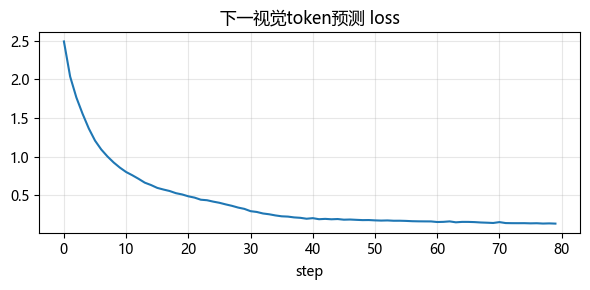

loss 2.491 → 0.132 (学会了视觉 token 序列的规律)


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
L = seqs.shape[1]; D = 32
class TinyImgGPT(nn.Module):
    def __init__(s):
        super().__init__()
        s.emb = nn.Embedding(K, D); s.pos = nn.Parameter(torch.randn(1,L,D)*0.02)
        s.dec = nn.TransformerEncoder(nn.TransformerEncoderLayer(D,4,D*2,batch_first=True),2)
        s.head = nn.Linear(D, K)
    def forward(s, x):  # x: (B, L) token ids
        h = s.emb(x) + s.pos[:, :x.shape[1]]
        mask = torch.triu(torch.ones(x.shape[1], x.shape[1])*float('-inf'), 1)  # 因果掩码
        return s.head(s.dec(h, mask=mask))
model = TinyImgGPT()
X = torch.tensor(seqs[:, :-1]); Y = torch.tensor(seqs[:, 1:])
opt = torch.optim.Adam(model.parameters(), lr=5e-3); lossf = nn.CrossEntropyLoss()
losses=[]
for _ in range(80):
    opt.zero_grad(); logits = model(X)
    loss = lossf(logits.reshape(-1,K), Y.reshape(-1)); loss.backward(); opt.step()
    losses.append(loss.item())
plt.figure(figsize=(6,3)); plt.plot(losses); plt.title('下一视觉token预测 loss'); plt.xlabel('step'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"loss {losses[0]:.3f} → {losses[-1]:.3f} (学会了视觉 token 序列的规律)")

## 3. 采样生成一串新视觉 token → 解码成图 (让「LLM 画图」)

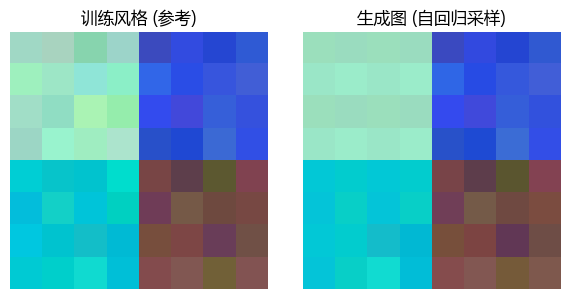

生成的视觉 token 序列: [3, 3, 4, 0, 3, 3, 9, 2, 10, 10, 6, 8, 10, 7, 1, 5]
→ 这就是 L2: 生成图 = 自回归生成视觉 token + 码本解码 (和生成文本同机制)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(1)
gen = [int(seqs[0,0])]   # 用第一个 token 起头
with torch.no_grad():
    for _ in range(L-1):
        logits = model(torch.tensor([gen]))[0, -1]
        probs = torch.softmax(logits/0.7, -1)        # temperature 采样 (L2)
        gen.append(int(torch.multinomial(probs, 1)))
gen = np.array(gen)
recon = vq.patches_to_image(vq.dequantize(gen, codebook), grid=4, patch=2)
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(np.clip(base,0,1)); ax[0].set_title('训练风格 (参考)'); ax[0].axis('off')
ax[1].imshow(np.clip(recon,0,1)); ax[1].set_title('生成图 (自回归采样)'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print(f"生成的视觉 token 序列: {gen.tolist()}")
print("→ 这就是 L2: 生成图 = 自回归生成视觉 token + 码本解码 (和生成文本同机制)。")

## 4. 反思 (10.4 收口)

你亲手让一个 tiny transformer 「画」了一张图: **VQ 离散化 (N1) + 自回归生成 token + 解码 (N2)**。带走:
- 生成图 = 自回归生成视觉 token, 文本生成的全套 (采样/temperature) 直接复用。
- 一个模型既能读图 (10.3) 又能画图 (10.4) → 理解+生成一体 (Chameleon, L3)。
- 推到极致 = any-to-any (L4), 瓶颈在 tokenizer; 跨模态迁移是 PhD gap。

> 交棒 10.5: any-to-any 还要 tokenize 音频和视频。怎么把视频 (图像+时序) 和音频变成 token?
> 下一专题 `video-audio-omni` 补齐时序模态。